In [20]:
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
# from matplotlib import rcParams #For changing text properties
# import cmocean #A package with beautiful colormaps
# from cartopy import crs as ccrs #Useful for plotting maps
# import cartopy.util #Requires separate import
# from cartopy.util import add_cyclic_point
# import cartopy.feature as cf
# from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
# import matplotlib.path as mpath
# import matplotlib.colors as mcolors
# from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
filename = '/nfs/spare11/env315/data/era5_u1060_daily_1980-2019.nc'
data = xr.open_dataset(filename).compute()
data = data.u_component_of_wind
data

0
1
2
3
5


/knight/mamba_aug23/envs/aug23_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gribberish' loading failed:
No module named 'gribberish'
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.DataArray 'u_component_of_wind' (time: 14610)>
array([33.964096, 37.398537, 38.92926 , ..., 41.941204, 40.91121 ,
       41.22743 ], dtype=float32)
Coordinates:
    lat      float64 60.0
    plev     float64 1e+03
  * time     (time) datetime64[ns] 1980-01-01T09:00:00 ... 2019-12-31T09:00:00

In [4]:
u1060 = data.sel(time=slice('2015-01-01','2019-12-31'))
u1060

<xarray.DataArray 'u_component_of_wind' (time: 1826)>
array([17.616823, 14.30596 , 13.591395, ..., 41.941204, 40.91121 ,
       41.22743 ], dtype=float32)
Coordinates:
    lat      float64 60.0
    plev     float64 1e+03
  * time     (time) datetime64[ns] 2015-01-01T09:00:00 ... 2019-12-31T09:00:00

Text(0.5, 1.0, 'Zonal mean U at 10 hPa and 60N from 2015-2019')

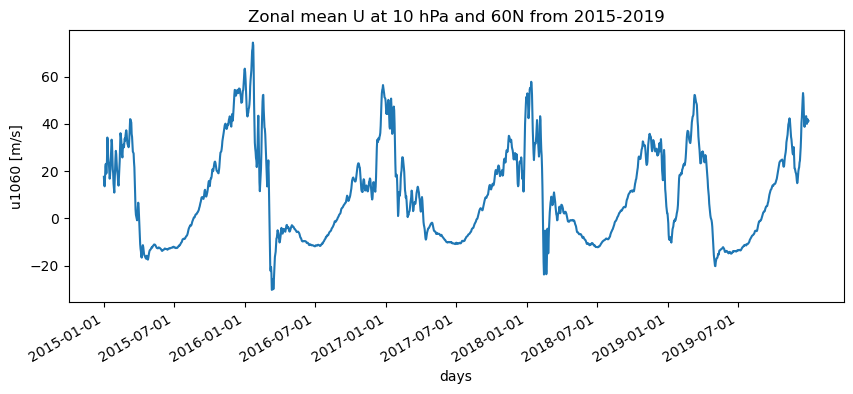

In [23]:
figure = plt.figure(figsize=(10,4))
plt.plot(u1060.time,u1060)

jan1_idx = pd.to_datetime([f'{year}-01-01' for year in range(2015, 2019 + 1)])
jul1_idx = pd.to_datetime([f'{year}-07-01' for year in range(2015, 2019 + 1)])

# Combine indices and sort
all_indices = np.sort(np.concatenate((jan1_idx, jul1_idx)))

# Set the x-axis ticks to January 1st and July 1st
plt.xticks(all_indices)
plt.gcf().autofmt_xdate()

plt.xlabel('days')
plt.ylabel('u1060 [m/s]')
plt.title('Zonal mean U at 10 hPa and 60N from 2015-2019')

In [25]:
filename = '/nfs/spare11/env315/data/era5_an_temp_reg2_daily_2021.nc'
data = xr.open_dataset(filename).compute()
data = data.var130
data

<xarray.DataArray 'var130' (time: 365, plev: 37, lat: 91, lon: 180)>
array([[[[264.1321 , 264.1321 , 264.1321 , ..., 264.1321 , 264.1321 ,
          264.1321 ],
         [266.73904, 266.77078, 266.7947 , ..., 266.5994 , 266.6536 ,
          266.70047],
         [271.13065, 271.17215, 271.19705, ..., 270.90506, 270.99588,
          271.07156],
         ...,
         [285.77713, 285.74393, 285.71365, ..., 285.8914 , 285.85135,
          285.81326],
         [286.0032 , 285.98416, 285.9656 , ..., 286.06326, 286.04227,
          286.02225],
         [286.74344, 286.74344, 286.74344, ..., 286.74344, 286.74344,
          286.74344]],

        [[258.1566 , 258.1566 , 258.1566 , ..., 258.1566 , 258.1566 ,
          258.1566 ],
         [258.27377, 258.41537, 258.55405, ..., 257.82895, 257.9808 ,
          258.12973],
         [261.8939 , 262.25278, 262.6043 , ..., 260.7811 , 261.1566 ,
          261.52768],
...
         [267.0744 , 266.97235, 266.85907, ..., 267.2907 , 267.2331 ,
          267.16083],
         [267.23553, 267.20575, 267.17157, ..., 267.30194, 267.28436,
          267.2624 ],
         [266.278  , 266.278  , 266.278  , ..., 266.278  , 266.278  ,
          266.278  ]],

        [[249.42935, 249.42935, 249.42935, ..., 249.42935, 249.42935,
          249.42935],
         [250.52505, 250.4816 , 250.44302, ..., 250.67154, 250.6193 ,
          250.57095],
         [251.43277, 251.39029, 251.34097, ..., 251.52945, 251.50162,
          251.46988],
         ...,
         [268.3439 , 268.2438 , 268.1315 , ..., 268.56314, 268.50455,
          268.4318 ],
         [268.56216, 268.52994, 268.49527, ..., 268.631  , 268.61295,
          268.5895 ],
         [267.52652, 267.52652, 267.52652, ..., 267.52652, 267.52652,
          267.52652]]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 90.0 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0 -90.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * plev     (plev) float64 100.0 200.0 300.0 500.0 ... 9.5e+04 9.75e+04 1e+05
  * time     (time) datetime64[ns] 2021-01-01T09:00:00 ... 2021-12-31T09:00:00
Attributes:
    table:         128
    cell_methods:  time: mean

In [27]:
temp_conus = data.sel(lon=slice(235,295),lat=slice(50,24.5),plev=100000,time='2021-01-19')
temp_conus.shape

(1, 13, 30)

In [28]:
temp_c = temp_conus-273.15
temp_c

<xarray.DataArray 'var130' (time: 1, lat: 13, lon: 30)>
array([[[  6.2719727 ,   5.8237305 ,   3.678711  ,   1.7416992 ,
           2.6279297 ,   4.826172  ,   4.9414062 ,   3.2646484 ,
           1.5556641 ,  -1.0385742 ,  -5.2177734 ,  -9.74707   ,
         -14.05957   , -17.66211   , -19.070312  , -18.688477  ,
         -18.325195  , -17.794922  , -16.71289   , -16.350586  ,
         -16.594727  , -16.018555  , -15.348145  , -16.186523  ,
         -17.90039   , -18.756836  , -18.135254  , -16.52539   ,
         -14.338379  , -11.237793  ],
        [  5.038086  ,   6.1557617 ,   5.7055664 ,   3.5405273 ,
           2.8935547 ,   4.3554688 ,   5.086914  ,   4.5219727 ,
           3.9038086 ,   2.4077148 ,  -0.51904297,  -3.9658203 ,
          -8.369629  , -13.333496  , -15.901855  , -15.495605  ,
         -14.254395  , -12.486816  , -10.425293  ,  -9.981934  ,
         -10.825684  , -11.047852  , -11.206055  , -12.402344  ,
         -13.891602  , -14.779297  , -14.644531  , -13.409668  ,
         -11.7109375 ,  -9.589844  ],
        [  6.583008  ,   6.4316406 ,   5.5283203 ,   4.3549805 ,
           3.8134766 ,   3.9472656 ,   4.1054688 ,   4.551758  ,
           5.1367188 ,   4.2192383 ,   2.0737305 ,   0.39111328,
          -2.1357422 ,  -6.678711  , -10.325684  , -11.148926  ,
...
          15.47168   ,  14.527832  ,  13.85498   ,  13.083984  ,
          12.256348  ,  12.506836  ,  13.783691  ,  14.703125  ,
          15.298828  ,  16.089844  ,  16.513672  ,  17.111328  ,
          17.796875  ,  18.44336   ],
        [ 15.893066  ,  15.429199  ,  14.5859375 ,  14.779785  ,
          15.922852  ,  17.03125   ,  19.127441  ,  21.567871  ,
          24.34961   ,  26.368164  ,  26.27539   ,  23.873535  ,
          21.068848  ,  20.555176  ,  19.846191  ,  18.40332   ,
          17.868164  ,  17.234375  ,  16.480957  ,  15.008789  ,
          13.31543   ,  13.9375    ,  15.87793   ,  16.47754   ,
          16.885742  ,  17.909668  ,  18.246582  ,  18.713867  ,
          19.402344  ,  19.96289   ],
        [ 16.850586  ,  16.205566  ,  15.880859  ,  16.422363  ,
          16.692383  ,  17.47754   ,  18.96875   ,  19.79248   ,
          22.480469  ,  26.42627   ,  28.70459   ,  27.990723  ,
          23.762207  ,  21.160645  ,  20.92334   ,  19.560547  ,
          19.214355  ,  19.510254  ,  19.059082  ,  17.68164   ,
          15.773926  ,  16.31836   ,  17.80957   ,  18.20166   ,
          18.986328  ,  19.836426  ,  20.206055  ,  20.770996  ,
          21.315918  ,  21.607422  ]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 50.0 48.0 46.0 44.0 42.0 ... 34.0 32.0 30.0 28.0 26.0
  * lon      (lon) float64 236.0 238.0 240.0 242.0 ... 288.0 290.0 292.0 294.0
    plev     float64 1e+05
  * time     (time) datetime64[ns] 2021-01-19T09:00:00